<a href="https://colab.research.google.com/github/steffyjohnson/COGNOS/blob/main/ConstructionRiskAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import matplotlib.pyplot as plt


In [36]:
construction =pd.read_csv("construction_dataset[1].csv")

The command .head() shows the first 5 rows of the dataset.
Helps us to verify:
the file loaded is correct;
column names are correct;
data looks reasonable;


In [37]:
construction.head()

,Task_ID,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Risk_Level,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count
0,T1,52,14,6,16789.73,0,Medium,0.41,0.59,4
1,T2,15,2,2,16885.80,5,Low,0.75,0.17,3
2,T3,72,11,1,7978.70,22,Low,0.96,0.41,1
3,T4,61,1,5,19379.02,18,Low,0.41,0.67,4
4,T5,21,19,5,66757.72,22,Low,0.85,0.63,3


From the task T5:
Task_ID = T5
Duration = 21 days
Labor = 19 workers
Cost = $60,757
Risk = Low

eventhough the risk is low; cost is very high;
this is the kind of insight we will explore

In [38]:
construction.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Task_ID                    1300 non-null   object 
 1   Task_Duration_Days         1300 non-null   int64  
 2   Labor_Required             1300 non-null   int64  
 3   Equipment_Units            1300 non-null   int64  
 4   Material_Cost_USD          1300 non-null   float64
 5   Start_Constraint           1300 non-null   int64  
 6   Risk_Level                 1300 non-null   object 
 7   Resource_Constraint_Score  1300 non-null   float64
 8   Site_Constraint_Score      1300 non-null   float64
 9   Dependency_Count           1300 non-null   int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 101.7+ KB


The info() function provides a summary of the dataset including:
- Number of rows and columns
- Data types
- Missing values
- Memory usage

This helps us understand the quality and structure of the data before analysis.


In [39]:
construction.isnull().sum()

,0
Task_ID,0
Task_Duration_Days,0
Labor_Required,0
Equipment_Units,0
Material_Cost_USD,0
Start_Constraint,0
Risk_Level,0
Resource_Constraint_Score,0
Site_Constraint_Score,0
Dependency_Count,0


### Findings

The missing value analysis showed that all columns contain complete data with no null values.

This indicates good data quality and allows further analysis without requiring data cleaning or imputation techniques.

In [40]:
construction["Risk_Level"].value_counts()

,count
Risk_Level,
Low,660
Medium,377
High,263


### Risk Level Analysis

The dataset contains 1,300 construction tasks.
percentage=[risk number/total no. of construction tasks]*100

- Low Risk Tasks: 660 (50.8%)
- Medium Risk Tasks: 377 (29.0%)
- High Risk Tasks: 263 (20.2%)

The majority of tasks are classified as Low Risk. However, 263 tasks are considered High Risk and may require additional monitoring, resource planning, and mitigation strategies to prevent project delays and cost overruns.

In [41]:
risk_counts=construction["Risk_Level"].value_counts()
risk_percentage=(risk_counts/len(construction)*100)
print(risk_percentage)
print(risk_percentage.round(2))

Risk_Level
Low       50.769231
Medium    29.000000
High      20.230769
Name: count, dtype: float64
Risk_Level
Low       50.77
Medium    29.00
High      20.23
Name: count, dtype: float64


Percentages provide a normalized view of the data. They make it easier to compare risk levels and communicate findings regardless of dataset

# Material cost analysis:
Material costs are one of the largest contributors to construction project expenses. This analysis identifies the top 10 tasks with the highest material costs.

In [42]:
construction.sort_values(by="Material_Cost_USD", ascending=False).head(10)

,Task_ID,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Risk_Level,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count
477,T478,51,7,3,99956.21,21,High,0.81,0.73,3
230,T231,20,1,9,99890.37,17,Low,0.83,0.62,3
1084,T1085,31,18,3,99777.19,7,Medium,0.33,0.12,0
235,T236,19,1,2,99765.20,18,Low,0.79,0.32,4
330,T331,53,6,4,99726.55,3,Low,0.86,0.79,2
129,T130,65,7,5,99721.05,6,Medium,0.83,0.42,2
1290,T1291,57,1,8,99656.10,2,High,0.33,0.76,0
223,T224,11,19,5,99619.61,27,Low,0.45,0.28,3
271,T272,75,6,9,99567.48,15,Low,0.38,0.61,4
1003,T1004,23,8,5,99561.32,20,Low,0.49,0.82,0


### Material Cost Analysis

The top 10 most expensive construction tasks were identified based on material costs.

Key observations:

- Task T478 had the highest material cost at approximately $99,956.
- Several high-cost tasks were classified as Low Risk, indicating that project cost alone is not a reliable indicator of project risk.
- Task T478 was both High Risk and high cost, making it a critical task that may require additional monitoring and mitigation planning.

These findings demonstrate the importance of evaluating cost and risk together when prioritizing project activities.

In [43]:
construction.groupby("Risk_Level")["Material_Cost_USD"].mean().round(2)

,Material_Cost_USD
Risk_Level,
High,48411.48
Low,49751.73
Medium,49905.26


"The analysis showed that average material costs were similar across all risk categories. This suggests that risk is driven by operational constraints rather than material spending alone."

The task is risky not just because of cost, but because:

1. Resource Constraint Score = 0.81

This is quite high.

It suggests resources may be difficult to obtain or allocate.

Business impact:

If workers or equipment are unavailable, the task could be delayed.

2. Site Constraint Score = 0.73

Also high.

Business impact:

Physical site conditions, access restrictions, weather, or location issues could affect execution.

3. Dependency Count = 3

This task depends on other tasks.

Business impact:

If one upstream task is delayed, this task may also be delayed.

4. Duration = 51 Days

A long-duration task has more opportunities for problems to occur.

Business impact:

The longer the task, the greater the exposure to risk.

This is a much stronger insight

Instead of writing:

"Task T478 is high risk because it costs a lot."

### Critical Task Analysis

Task T478 was identified as a critical task due to its combination of:

- High material cost ($99,956)
- High resource constraint score (0.81)
- High site constraint score (0.73)
- Multiple task dependencies (3)
- Long duration (51 days)

These factors increase the likelihood of project delays and operational challenges, making this task a priority for management attention.

In [44]:
construction.corr(numeric_only=True)

,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count
Task_Duration_Days,1.000000,0.051290,0.006068,0.015340,-0.009244,-0.027677,-0.062465,-0.021334
Labor_Required,0.051290,1.000000,0.001091,-0.022775,-0.007913,-0.036116,-0.034345,-0.000819
Equipment_Units,0.006068,0.001091,1.000000,-0.070180,-0.032430,0.009417,0.035187,0.052694
Material_Cost_USD,0.015340,-0.022775,-0.070180,1.000000,-0.018832,-0.013648,0.021078,-0.022864
Start_Constraint,-0.009244,-0.007913,-0.032430,-0.018832,1.000000,0.035345,-0.007680,-0.005615
Resource_Constraint_Score,-0.027677,-0.036116,0.009417,-0.013648,0.035345,1.000000,0.034524,0.065806
Site_Constraint_Score,-0.062465,-0.034345,0.035187,0.021078,-0.007680,0.034524,1.000000,0.043184
Dependency_Count,-0.021334,-0.000819,0.052694,-0.022864,-0.005615,0.065806,0.043184,1.000000


# What is a correlation?

A correlation measures how strongly two variables move together.

Values range from:

+1.0  = Perfect positive relationship
 0.0  = No relationship
-1.0  = Perfect negative relationship

Rule of thumb:

Correlation	Interpretation
0.00 - 0.19	Very weak
0.20 - 0.39	Weak
0.40 - 0.59	Moderate
0.60 - 0.79	Strong
0.80 - 1.00	Very strong

**Most of your correlations are very close to 0.**

For example:

Task_Duration_Days vs Material_Cost_USD = 0.015

That's basically no relationship.

Meaning:

Longer tasks are not necessarily more expensive.

Material_Cost_USD vs Equipment_Units = -0.070

Again, almost no relationship.

Meaning:

Tasks requiring more equipment do not necessarily have higher material costs.

# Most interesting relationship

The largest correlation I see is:

Resource_Constraint_Score vs Dependency_Count = 0.066

Even this is extremely weak.

Meaning:

Tasks with more dependencies may have slightly higher resource constraints, but the relationship is very small.

## Correlation Analysis

A correlation analysis was performed to identify relationships between construction project variables.

Key findings:

- Most variables showed very weak correlations.
- Material cost was not strongly related to task duration, labor requirements, or equipment usage.
- Resource constraints and dependency counts showed a slight positive relationship.
- The absence of strong correlations suggests that project complexity is influenced by multiple independent factors rather than a single dominant variable.

These findings highlight the importance of evaluating multiple project metrics when assessing construction project performance and risk.

Why is this happening?

Because this is a synthetic Kaggle dataset.

The dataset appears to have been generated randomly.

That's why:

High Cost ≠ High Risk
Long Duration ≠ High Cost
More Labor ≠ More Risk

In real construction data, we would normally expect stronger relationships.

# Critical Task Score

In [45]:
construction["Critical_Task_Score"] = (
    construction["Dependency_Count"] * 2
    + construction["Resource_Constraint_Score"] * 10
    + construction["Site_Constraint_Score"] * 10
)

construction[
    [
        "Task_ID",
        "Risk_Level",
        "Critical_Task_Score"
    ]
].sort_values(
    by="Critical_Task_Score",
    ascending=False
).head(10)

,Task_ID,Risk_Level,Critical_Task_Score
1090,T1091,Low,26.0
288,T289,Medium,25.9
995,T996,Low,25.8
460,T461,Low,25.5
1045,T1046,High,25.3
113,T114,Medium,25.2
592,T593,Low,25.2
759,T760,Medium,25.1
899,T900,High,25.0
499,T500,Medium,24.9


Why this is powerful

You're creating your own business metric.

This is something you can say in an interview:

"I developed a Critical Task Score that combines dependency count, resource constraints, and site constraints to identify construction activities requiring management attention."

That sounds much more impressive than:

"I plotted a correlation matrix."

# Interesting Finding

Look at the highest-ranked task:

T1091
Risk Level = Low
Critical Task Score = 26.0

At first this seems strange.

Why?

Because the dataset's Risk_Level says "Low".

But our custom score says:

"This task deserves attention."

This is actually a realistic business scenario.

## Critical Task Score Analysis

A custom Critical Task Score was developed to identify tasks that may require additional management attention.

The score combines:

- Dependency Count
- Resource Constraint Score
- Site Constraint Score

Key observations:

- Several tasks with Low Risk classifications received high Critical Task Scores.
- This suggests that operational complexity may not always be reflected in the assigned risk category.
- Custom business metrics can provide additional insights beyond standard project classifications.

This analysis demonstrates how data-driven scoring models can support project planning and risk management.

# Step 1: Create a Better Critical Score
## Enhanced Critical Task Score

The initial Critical Task Score considered operational constraints. An enhanced score was developed by incorporating project risk levels to provide a more comprehensive assessment of task criticality.

Components:
- Risk Level
- Dependency Count
- Resource Constraint Score
- Site Constraint Score

In [46]:
risk_map = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

construction["Risk_Score"] = construction["Risk_Level"].map(risk_map)

Explanation
Low Risk = 1
Medium Risk = 2
High Risk = 3

We're converting text into numbers because Python cannot perform calculations on words.

# ENHANCED Critical Score

In [47]:
construction["Enhanced_Critical_Score"] = (
    construction["Risk_Score"] * 5
    + construction["Dependency_Count"] * 2
    + construction["Resource_Constraint_Score"] * 10
    + construction["Site_Constraint_Score"] * 10
)

construction[
    [
        "Task_ID",
        "Risk_Level",
        "Enhanced_Critical_Score"
    ]
].sort_values(
    by="Enhanced_Critical_Score",
    ascending=False
).head(10)

,Task_ID,Risk_Level,Enhanced_Critical_Score
1045,T1046,High,40.3
899,T900,High,40.0
502,T503,High,39.7
723,T724,High,39.7
1132,T1133,High,39.6
497,T498,High,39.2
262,T263,High,39.0
143,T144,High,38.9
283,T284,High,38.5
522,T523,High,38.5


Understanding the Formula

Suppose:

Risk Score = 3
Dependency Count = 4
Resource Constraint = 0.8
Site Constraint = 0.7

Calculation:

(3 × 5)
+ (4 × 2)
+ (0.8 × 10)
+ (0.7 × 10)

= 15 + 8 + 8 + 7

= 38
Higher score = Higher priority.

# Step 3: Create Your First "Management Dashboard" Chart

## Top 10 Critical Tasks

This visualization highlights the highest-priority tasks based on the Enhanced Critical Score.

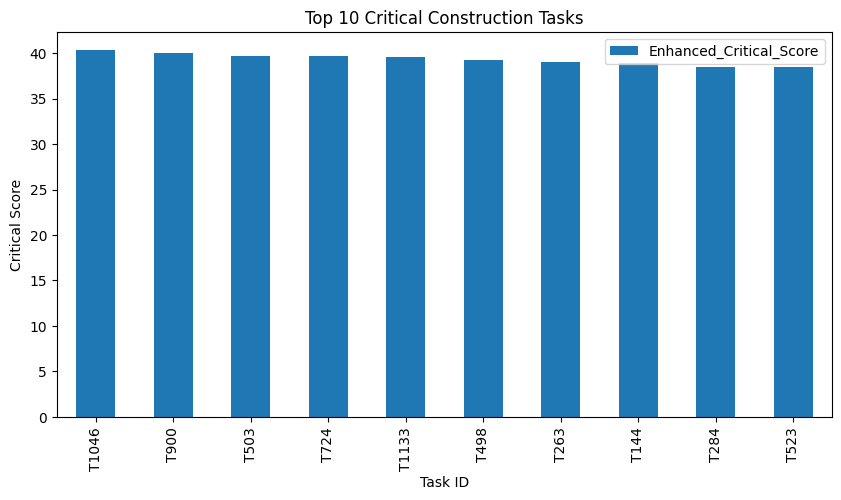

In [48]:
top_tasks = construction.sort_values(
    by="Enhanced_Critical_Score",
    ascending=False
).head(10)

top_tasks.plot(
    x="Task_ID",
    y="Enhanced_Critical_Score",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Critical Construction Tasks")
plt.ylabel("Critical Score")
plt.xlabel("Task ID")

plt.show()